In [1]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Keerthana gowda
[nltk_data]     v\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [15]:
import pandas as pd

data = pd.read_csv(r"C:\Users\Keerthana gowda v\Downloads\customer_support_tickets.csv")

data.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [16]:
data.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [17]:
data['text'] = data['Ticket Subject'] + " " + data['Ticket Description']

data[['text','Ticket Type','Ticket Priority']].head()

,text,Ticket Type,Ticket Priority
0,Product setup I'm having an issue with the {pr...,Technical issue,Critical
1,Peripheral compatibility I'm having an issue w...,Technical issue,Critical
2,Network problem I'm facing a problem with my {...,Technical issue,Low
3,Account access I'm having an issue with the {p...,Billing inquiry,Low
4,Data loss I'm having an issue with the {produc...,Billing inquiry,Low


In [18]:
import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

data['clean_text'] = data['text'].apply(clean_text)

data[['clean_text']].head()

[nltk_data] Downloading package stopwords to C:\Users\Keerthana gowda
[nltk_data]     v\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,clean_text
0,product setup im issue productpurchased please...
1,peripheral compatibility im issue productpurch...
2,network problem im facing problem productpurch...
3,account access im issue productpurchased pleas...
4,data loss im issue productpurchased please ass...


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(data['clean_text'])

In [20]:
y_category = data['Ticket Type']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_category,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.1959858323494687
                      precision    recall  f1-score   support

     Billing inquiry       0.19      0.13      0.16       357
Cancellation request       0.19      0.20      0.19       327
     Product inquiry       0.18      0.18      0.18       316
      Refund request       0.19      0.21      0.20       345
     Technical issue       0.22      0.26      0.24       349

            accuracy                           0.20      1694
           macro avg       0.19      0.20      0.19      1694
        weighted avg       0.19      0.20      0.19      1694



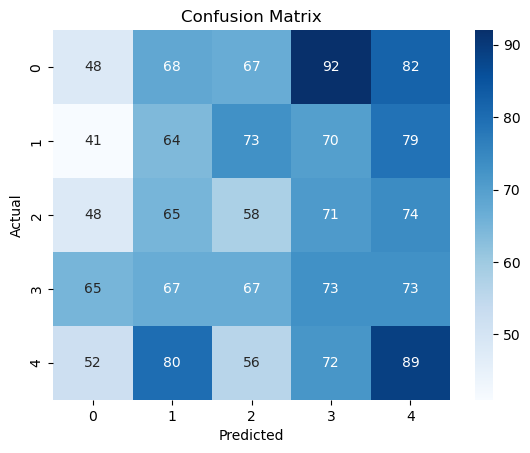

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
y_priority = data['Ticket Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_priority,
    test_size=0.2,
    random_state=42
)

priority_model = LogisticRegression(max_iter=200)

priority_model.fit(X_train, y_train)

priority_pred = priority_model.predict(X_test)

print("Priority Accuracy:", accuracy_score(y_test, priority_pred))

Priority Accuracy: 0.2733175914994097


In [27]:
new_ticket = ["My account is locked and I cannot login"]

clean = clean_text(new_ticket[0])

vector = vectorizer.transform([clean])

prediction = model.predict(vector)

priority = priority_model.predict(vector)

print("Predicted Category:", prediction[0])
print("Predicted Priority:", priority[0])

Predicted Category: Billing inquiry
Predicted Priority: High
